<a href="https://colab.research.google.com/github/Dayaanaly/U-Net-vs-SegNet/blob/main/SegNet_vs_Unet_AM_DAPB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Segmentación automática de estructuras de rodilla en imágenes de resonancia magnética mediante comparación de arquitecturas U-Net y SegNet**

*Centro Universitario de Ciencias Exactas e Ingenierías*\
*División de Tecnologías para la Integración Ciber-Humana*\
*Maestría en Ciencias en Róbotica e Inteligencia Artificial*
# ***********************************
<br>

Dr. Carlos Alberto Villaseñor Padilla\
26 de Mayo de 2026



**``NOMBRE:``**
Dayana Analy Pacheco Bañuelos\
**``CÓDIGO:``**
217535226\
**```LINK REPOSITORIO:```**
https://github.com/Dayaanaly/U-Net-vs-SegNet/tree/main

## **Contenido**

1.   Problema
2.   Marco teórico
3.   Materiales y métodos
4.   Código
5.   Resultados
6.   Conclusiones
7.   Referencias



#**1. Problema**

La segmentación de estructuras anatómicas en imágenes médicas es una tarea
importante dentro del análisis asistido por computadora, ya que permite
identificar regiones de interés de manera automática. En este proyecto se aborda la segmentación multiclase de estructuras de rodilla en imágenes de resonancia magnética, específicamente la identificación de fémur, tibia, rótula y fondo.

Este problema es relevante porque la segmentación manual puede ser tardada, depender del criterio del especialista y presentar variaciones entre observadores. Por ello, el uso de redes neuronales convolucionales permite automatizar el proceso y obtener máscaras de segmentación que pueden servir como base para análisis posteriores.

# **2. Marco Teórico**
La detección precisa de anomalías en la rótula a partir de resonancias magnéticas un desafío significativo en el ámbito de la salud [1]. Se identificó la necesidad de contar con una herramienta tecnológica que automatice el proceso de análisis, reduciendo la posibilidad de errores y acelerando la toma de decisiones en el diagnóstico [2].

**Red U-Net**\
U-Net es un tipo de red neuronal que se utiliza principalmente para la segmentación de imágenes, es decir, para dividir una imagen en diferentes partes e identificar objetos específicos; por ejemplo, para separar un tumor del tejido sano en una tomografía médica. El nombre "U-Net" proviene de la forma de su arquitectura, que se asemeja a la letra "U" al dibujarla. Se utiliza ampliamente en imágenes médicas porque ofrece un buen rendimiento incluso con una pequeña cantidad de datos etiquetados [3].

Implementación de U-Net\
Ahora implementaremos la arquitectura U-Net utilizando Python 3 y la biblioteca TensorFlow. La implementación consta de tres partes principales:

*   Bloque codificador: El bloque de ruta de contracción contiene dos capas convolucionales de 3x3 con activaciones ReLU, seguidas de una capa de agrupación máxima de 2x2.
*   Bloque decodificador: El bloque de ruta expansiva que aumenta la frecuencia de muestreo de la entrada, la concatena con las características del codificador correspondientes y aplica dos capas convolucionales de 3x3 con funciones de activación ReLU.
*   Modelo U-Net: Combinación de los bloques codificador y decodificador para definir la arquitectura completa de U-Net.
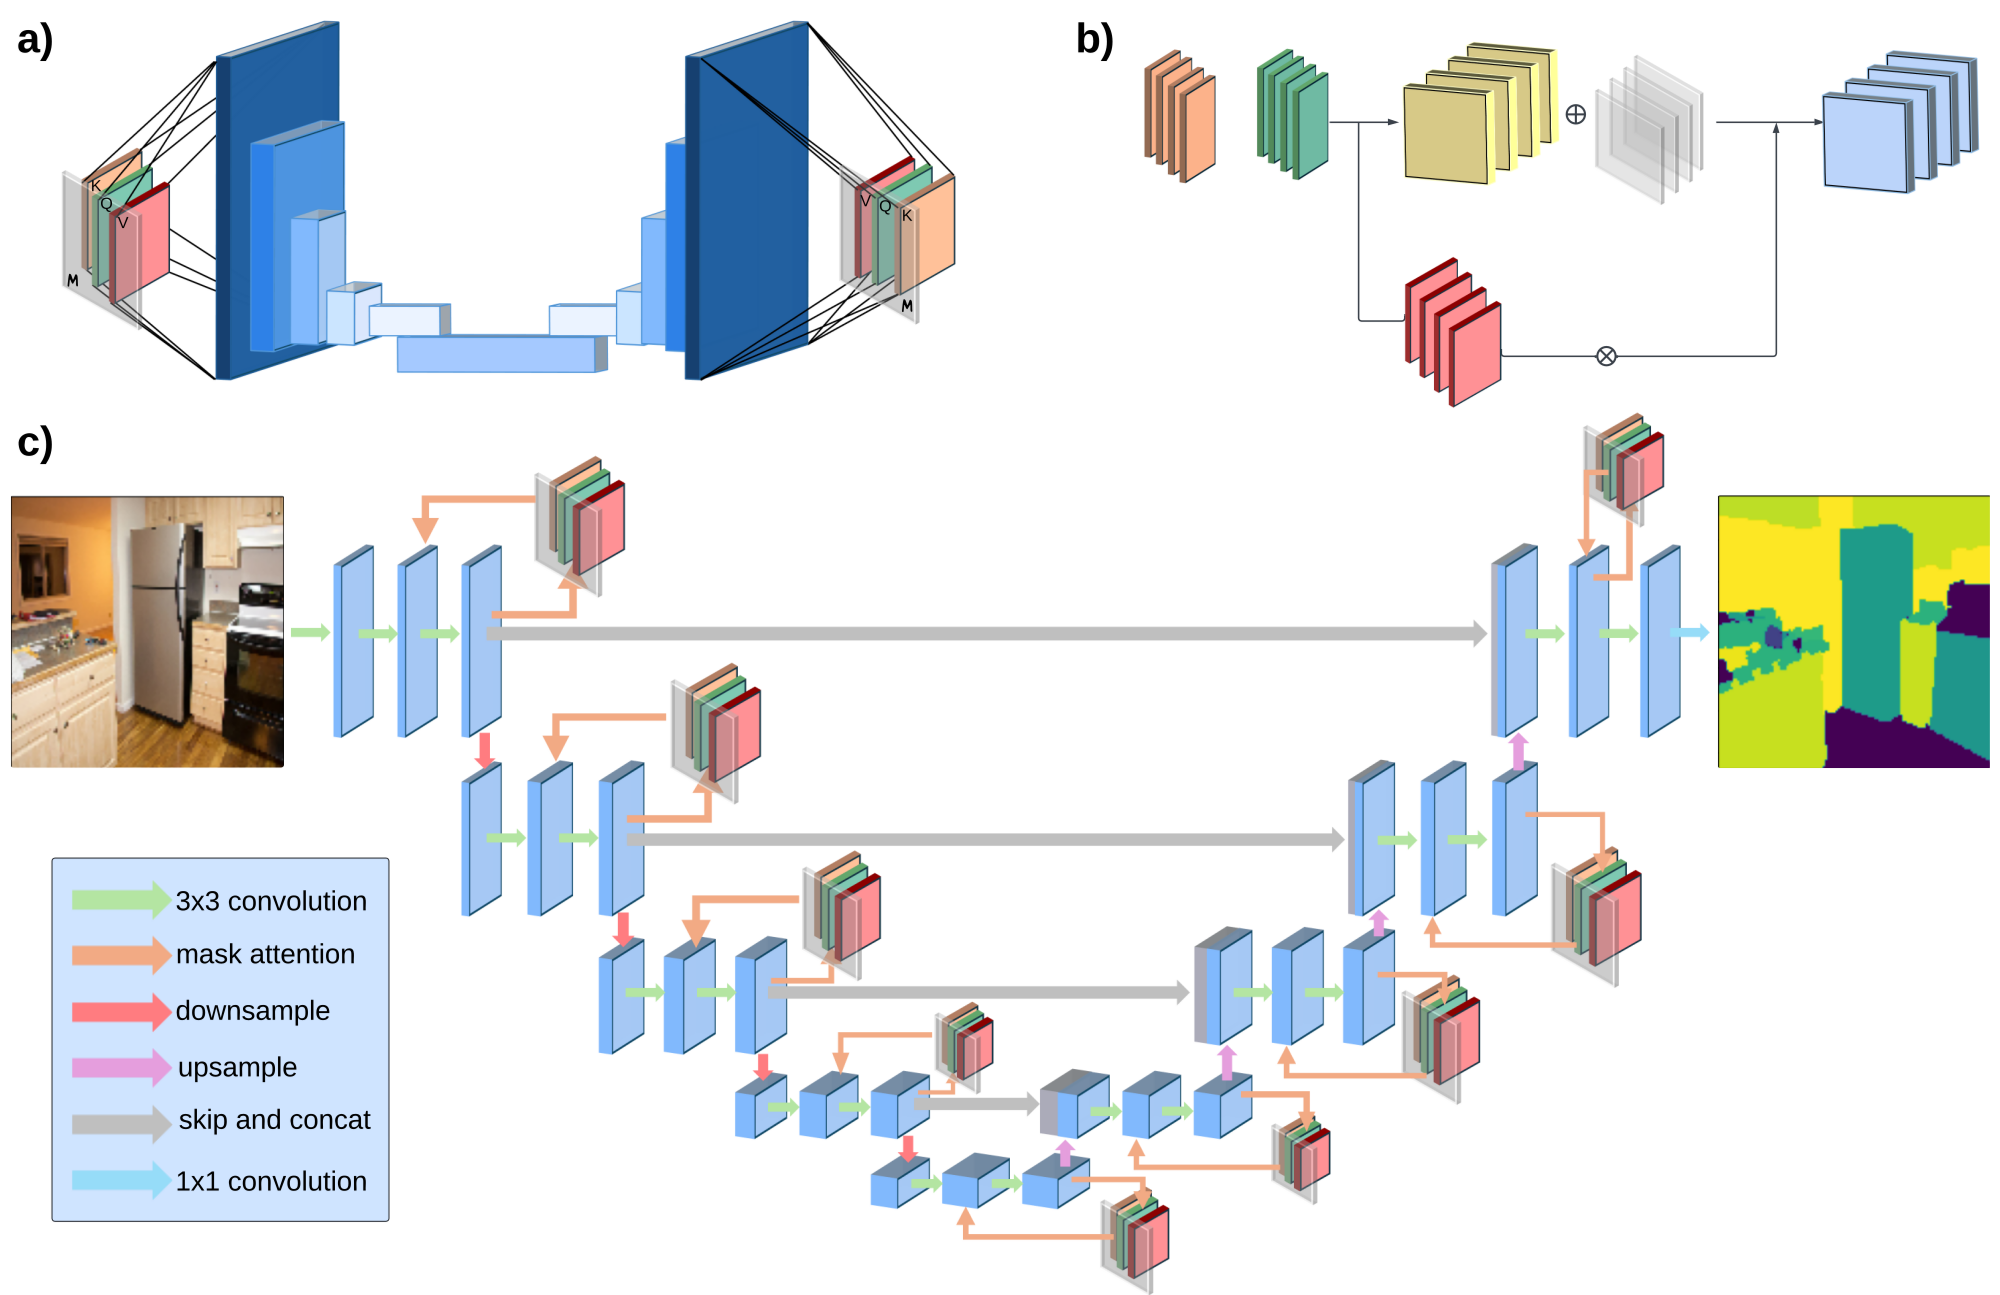

**Red SegNet**\
SegNet es una influyente red neuronal convolucional profunda para la segmentación semántica. Su arquitectura consta de una red codificadora, una red decodificadora y una capa final de clasificación píxel a píxel.

Tanto en la parte del codificador como en la del decodificador de la arquitectura SegNet, las capas convolucionales siguen un patrón similar:

Tienen un número predefinido de canales de entrada y salida.
Tener un tamaño de kernel de 3 con relleno de 1.
Los mapas de características resultantes se someten a una normalización por lotes y, posteriormente, se pasan a una función de activación no lineal rectificada (ReLU) elemento a elemento.

Bloque codificador\
La parte codificadora de la red consta de múltiples bloques, donde los canales de entrada y salida de la primera capa convolucional varían en tamaño, mientras que las capas siguientes los tienen constantes ( in_c if i == 0 else out_c).

A continuación, se aplica la operación de agrupación máxima con un tamaño de núcleo de 2 y un paso de 2, conservando los índices (ubicaciones del valor máximo de la característica en cada ventana de agrupación).

Bloque decodificador\
Los índices de agrupación máxima de los mapas de características del codificador se almacenan y se utilizan en el decodificador para realizar el sobremuestreo de los mapas de características[4].

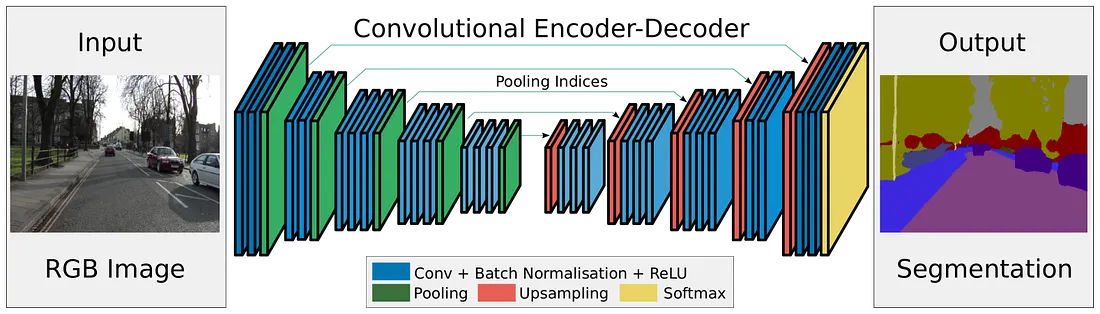

# **4. Materiales y métodos**
## *Materiales*

Se emplearon dos bases de datos —KneeScans de Henry Haefliger [7] y kneeMRIdataset de Sohaib Anwaar [8]— de
las cuales seleccionamos 400 imágenes de resonancia
magnética en plano sagital tipo T1. Estas secuencias T1 ofrecen
mayor calidad, riqueza de contraste y es ideal para visualizar la
estructura ósea de la articulación de la rodilla, ya que el tiempo
de relajación T1 corresponde al período en que un 63 % de la
magnetización longitudinal de un tejido se recupera tras un
pulso de radiofrecuencia, es decir, mide la velocidad con la que
los protones vuelven a alinearse con el campo magnético
principal. De las 400 imágenes, utilizamos 200 para la fase de
segmentación; además, un médico traumatólogo confirmó que
el 50 % de las muestras presentan lesiones rotulianas
(luxaciones o dislocaciones) y el otro 50 % corresponde a
rodillas sanas.

Las máscaras contienen etiquetas enteras, donde cada valor representa una clase específica. En este caso, la clase 0 corresponde al fondo, la clase 1 al fémur, la clase 2 a la tibia y la clase 3 a la rótula.

Para evaluar la generalización de los modelos, los datos se dividieron en 80% para entrenamiento y 20% para validación. Además, se aplicó aumento de datos mediante rotaciones, desplazamientos, zoom y volteo horizontal, con el objetivo de que la red no memorice únicamente las imágenes originales, sino que aprenda patrones más generales.


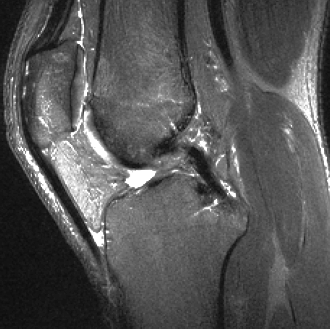
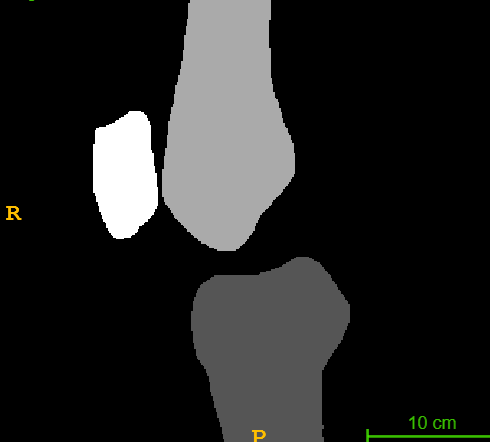

## *Métodos*
Este código implementa una comparativa entre U-Net y SegNet para segmentación semántica de imágenes de rodilla. Primero se cargan las imágenes y sus máscaras desde Google Drive. Las imágenes se normalizan entre 0 y 1, mientras que las máscaras se conservan como etiquetas enteras, ya que cada píxel representa una clase: fondo, fémur, tibia o rótula. También se corrige la orientación de las máscaras mediante rotación, redimensionamiento con interpolación por vecino más cercano y volteo horizontal.

La primera arquitectura U-Net, que tiene una estructura encoder-decoder. El encoder reduce la imagen y extrae características, mientras que el decoder recupera la resolución para generar la máscara. La ventaja principal de U-Net son sus conexiones de salto, que conectan el encoder con el decoder y ayudan a conservar detalles finos como bordes y contornos. La segunda arquitectura es SegNet, que también usa encoder-decoder, pero no tiene conexiones de salto.

Ambos modelos se entrenan bajo las mismas condiciones: mismo optimizador Adam, misma función de pérdida, mismas métricas y mismo conjunto de datos. La pérdida combina Sparse Categorical Crossentropy con Dice Loss, de manera que el modelo aprende a clasificar cada píxel y también a mejorar el solapamiento entre la máscara predicha y la máscara real.

Finalmente, los modelos se comparan con métricas como Pixel Accuracy, Dice e IoU. Aunque la exactitud por píxel es útil, Dice e IoU son más importantes en segmentación médica porque miden qué tan bien coincide la región segmentada con la estructura real


#**5. Código**

Instalar librería para archivos .nrrd

In [ ]:
!pip install pynrrd

In [ ]:
#Notitas para explicación del código

Montar Google Drive

In [ ]:
from google.colab import drive
import os

# Si Drive ya está montado, no lo vuelve a montar
if os.path.exists('/content/drive/MyDrive'):
    print("Google Drive ya está montado.")
else:
    drive.mount('/content/drive')


Mounted at /content/drive


Librerías

In [ ]:
#Librerias
# -------
import os
import time
import cv2
import nrrd
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model

Parámetros y directorios para rótula


In [ ]:
# Directorios de imágenes y máscaras
# -----------------------------------
image_dir = '/content/drive/MyDrive/Equipo Trifuerza/Datos/Data set grises/Dataset mezclado 2D'
mask_dir  = '/content/drive/MyDrive/Equipo Trifuerza/Datos/Data set grises/Mascaras mezcladas'

# Verificación rápida de rutas
print("Existe image_dir:", os.path.exists(image_dir))
print("Existe mask_dir:", os.path.exists(mask_dir))

if not os.path.exists(image_dir):
    raise FileNotFoundError(f"No existe la carpeta de imágenes: {image_dir}")

if not os.path.exists(mask_dir):
    raise FileNotFoundError(f"No existe la carpeta de máscaras: {mask_dir}")

# Parámetros de la imagen y segmentación
# ---------------------------------------
IMG_HEIGHT = 320
IMG_WIDTH = 224
IMG_CHANNELS = 1      # Imágenes en escala de grises
NUM_CLASSES = 4       # clases: fondo, fémur, tibia, rótula
batch_size = 8

# Parámetros ajustables del entrenamiento
# ---------------------------------------
# Para entrenar tanto U-Net como SegNet, con las mismas condiciones experimentales

LEARNING_RATE = 3e-4      # Más bajo para aprender con pasos más estables
EPOCHS = 80               # Más épocas, pero EarlyStopping detiene si no mejora
PATIENCE = 10             # Más paciencia para evitar detener demasiado pronto
SMOOTH = 1e-6

# Dropout reducido
# Se reduce porque el modelo no muestra overfitting fuerte.
# Demasiado dropout puede dificultar que el entrenamiento alcance a validación.
DROPOUT_LOW = 0.05
DROPOUT_MID = 0.10
DROPOUT_DEEP = 0.20

# Semilla para reproducibilidad
SEED = 42

tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# Carpeta de resultados
# ---------------------
output_dir = '/content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_80e'
os.makedirs(output_dir, exist_ok=True)

print("Los modelos y resultados se guardarán en:")
print(output_dir)

Existe image_dir: True
Existe mask_dir: True
Los modelos y resultados se guardarán en:
/content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_80e


Preprocesamiento

Cantidad de imágenes: 200
Cantidad de máscaras: 200
Forma de images: (200, 320, 224, 1)
Forma de masks: (200, 320, 224, 1)
Valores únicos en masks: [0 1 2 3]
Imágenes entrenamiento: (160, 320, 224, 1)
Máscaras entrenamiento: (160, 320, 224, 1)
Imágenes validación: (40, 320, 224, 1)
Máscaras validación: (40, 320, 224, 1)


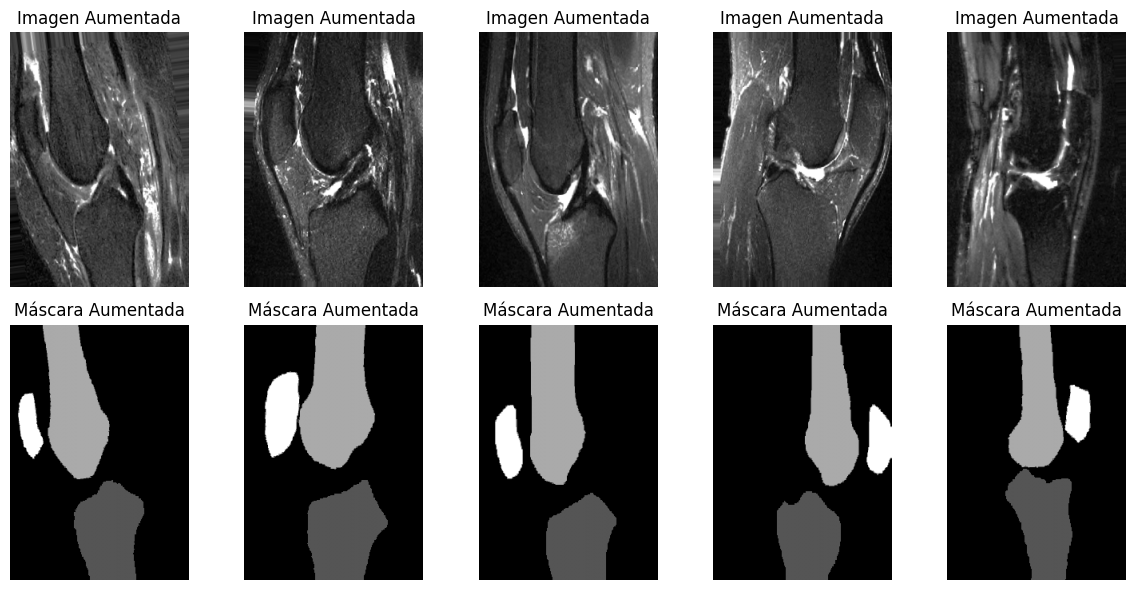

In [ ]:
# Filtrar archivos válidos (.nrrd y .bmp)
# ----------------------------------------
valid_extensions = ('.nrrd', '.bmp')

image_files = sorted([f for f in os.listdir(image_dir)
    if f.lower().endswith(valid_extensions)])
mask_files = sorted([f for f in os.listdir(mask_dir)
    if f.lower().endswith(valid_extensions)])

print("Cantidad de imágenes:", len(image_files))
print("Cantidad de máscaras:", len(mask_files))

assert len(image_files) == len(mask_files), "La cantidad de imágenes y máscaras debe ser la misma"

# Función para cargar imágenes
# ----------------------------
def load_image_custom(filepath, target_size=(IMG_HEIGHT, IMG_WIDTH), color_mode='grayscale'):
    ext = os.path.splitext(filepath)[1].lower()

    if ext == '.nrrd':
        # Cargar usando la librería nrrd
        img_data, header = nrrd.read(filepath)

        # Dependiendo del color_mode, procesamos la imagen
        if color_mode == 'grayscale':
            # Si la imagen es a color, convertirla a escala de grises
            if img_data.ndim == 3 and img_data.shape[-1] > 1:
                img_data = np.mean(img_data, axis=-1)

            # Si queda una dimensión extra de canal, la eliminamos temporalmente
            if img_data.ndim == 3 and img_data.shape[-1] == 1:
                img_data = np.squeeze(img_data, axis=-1)

            # Redimensionar usando cv2
            img_resized = cv2.resize(img_data, (target_size[1], target_size[0]))

            # Agregar la dimensión del canal
            img_resized = np.expand_dims(img_resized, axis=-1)

            return img_resized

        elif color_mode == 'rgb':
            # -Si es color, se espera que la imagen tenga 3 canales
            # -En caso de tener una sola banda, se replicará
            if img_data.ndim == 2:
                img_data = np.stack((img_data,) * 3, axis=-1)
            img_resized = cv2.resize(img_data, (target_size[1], target_size[0]))

            return img_resized

        else:
            raise ValueError("Modo de color no soportado: " + color_mode)

    else:
        # Para otros formatos (.bmp), usamos load_img de Keras
        return img_to_array(load_img(filepath, target_size=target_size, color_mode=color_mode))

# Cargar y preprocesar imágenes y máscaras
# ----------------------------------------
images = []
masks = []

for img_file, msk_file in zip(image_files, mask_files):
    image_path = os.path.join(image_dir, img_file)
    mask_path  = os.path.join(mask_dir, msk_file)

    # Cargar la imagen y normalizar valores entre 0 y 1
    img = load_image_custom(image_path,target_size=(IMG_HEIGHT, IMG_WIDTH),
                             color_mode='grayscale')

    img = img.astype('float32') / 255.0

    # Cargar la máscara
    # -La máscara contiene índices de clase: 0, 1, 2, 3
    mask = load_image_custom(mask_path,target_size=(IMG_HEIGHT, IMG_WIDTH),
                            color_mode='grayscale')

    mask = mask.astype(np.int64)

    # Preprocesado
    # -Si la máscara trae canal extra, lo quitamos para trabajar en 2D
    if mask.ndim == 3 and mask.shape[-1] == 1: mask = np.squeeze(mask, axis=-1)

    # Rotar la máscara para corregir orientación
    mask = np.rot90(mask, k=3, axes=(0, 1))  # 90° horario

    # Redimensionar con INTER_NEAREST para conservar etiquetas enteras
    mask = cv2.resize(mask,(IMG_WIDTH, IMG_HEIGHT),interpolation=cv2.INTER_NEAREST)

    # VOLTEO HORIZONTAL para corregir el “espejo”
    mask = np.fliplr(mask)

    # Agregar la dimensión del canal para que la máscara tenga forma (alto, ancho, 1)
    mask = np.expand_dims(mask, axis=-1)

    images.append(img)
    masks.append(mask)

# Convertir listas a arrays de NumPy
# -----------------------------------
images = np.array(images)
masks  = np.array(masks)

# Verificación y corrección de dimensiones
# -images → (N, 320, 224, 1)
# -masks  → (N, 320, 224, 1)
if masks.ndim == 5:
    masks = np.squeeze(masks, axis=-1)

# Asegurar que las máscaras estén en formato entero
masks = masks.astype(np.int32)

# Limitar valores al rango correcto
masks = np.clip(masks, 0, NUM_CLASSES - 1)

print("Forma de images:", images.shape)
print("Forma de masks:", masks.shape)
print("Valores únicos en masks:", np.unique(masks))

# Dividir en conjuntos de entrenamiento y validación
# --------------------------------------------------
#         80% entrenamiento, 20% validación

images_train, images_val, masks_train, masks_val = train_test_split(
    images,masks,test_size=0.20,random_state=SEED,shuffle=True)

print("Imágenes entrenamiento:", images_train.shape)
print("Máscaras entrenamiento:", masks_train.shape)
print("Imágenes validación:", images_val.shape)
print("Máscaras validación:", masks_val.shape)

# Data augmentation
# -----------------
# Se usa augmentation moderado para mejorar generalización,
# pero sin deformar demasiado las estructuras anatómicas

data_gen_args = dict(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest')

# Generadores
image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen  = ImageDataGenerator(**data_gen_args)

# Ajuste
# -Útil si algún escalador lo requiere
image_datagen.fit(images_train, augment=True, seed=SEED)
mask_datagen.fit(masks_train,  augment=True, seed=SEED)

def crear_train_generator():
#Crea un generador para que las transformaciones aplicadas a imágenes
#también se apliquen a su máscara correspondiente
    train_img_gen = image_datagen.flow(images_train,batch_size=batch_size,
                                        seed=SEED)

    train_mask_gen = mask_datagen.flow(
        masks_train,
        batch_size=batch_size,
        seed=SEED
    )

    while True:
        imgs = next(train_img_gen)
        msks = next(train_mask_gen)

        # Corrección importante para máscaras
        # -----------------------------------
        # Las máscaras son etiquetas enteras:
        # 0 = fondo
        # 1 = fémur
        # 2 = tibia
        # 3 = rótula
        #
        # Después del aumento de datos pueden aparecer valores decimales,
        # por eso redondeamos y limitamos el rango.
        msks = np.rint(msks).astype(np.int32)
        msks = np.clip(msks, 0, NUM_CLASSES - 1)

        yield imgs, msks

# Visualizar algunas imágenes y máscaras aumentadas
# -----------------------------------------------
batch = next(crear_train_generator())

plt.figure(figsize=(12, 6))

for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(batch[0][i].squeeze(), cmap='gray')
    plt.title("Imagen Aumentada")
    plt.axis('off')

    plt.subplot(2, 5, i + 6)
    plt.imshow(batch[1][i].squeeze(), cmap='gray')
    plt.title("Máscara Aumentada")
    plt.axis('off')

plt.tight_layout()
plt.show()


Definición de la U-Net multiclase


*   Métricas + modelo



In [ ]:
#U-Net

# Métricas de segmentación
# -----------------------

#Prepara la máscara real para las métricas y la función de pérdida
def preparar_y_true(y_true):
    y_true = tf.cast(y_true, tf.int32)

    # Quitamos el canal extra de la máscara
    if y_true.shape.rank == 4:
        y_true = tf.squeeze(y_true, axis=-1)
    return y_true

#Dice promedio para segmentación multiclase
def mean_dice(y_true, y_pred):
    # -Dice= mide el solapamiento entre la máscara real y la predicha
    # -Valor cercano a 1 indica mejor segmentación
    y_true = preparar_y_true(y_true)

    # Convertimos la máscara real a one-hot
    y_true_one_hot = tf.one_hot(y_true, depth=NUM_CLASSES)

    # y_pred ya viene como probabilidades por softmax
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_one_hot = tf.cast(y_true_one_hot, tf.float32)

    # Calculamos Dice por clase
    axes = [0, 1, 2]

    intersection = tf.reduce_sum(y_true_one_hot * y_pred, axis=axes)
    denominator = tf.reduce_sum(y_true_one_hot + y_pred, axis=axes)

    dice = (2.0 * intersection + SMOOTH) / (denominator + SMOOTH)

    # Promediamos solo clases anatómicas: 1, 2 y 3
    dice_foreground = dice[1:]

    return tf.reduce_mean(dice_foreground)

# IoU promedio para segmentación multiclase
def mean_iou(y_true, y_pred):
    #IoU mide la intersección sobre la unión entre la máscara real y la predicha
    #Un valor cercano a 1 indica mejor segmentación
    y_true = preparar_y_true(y_true)

    # Convertimos la máscara real a one-hot
    y_true_one_hot = tf.one_hot(y_true, depth=NUM_CLASSES)

    y_pred = tf.cast(y_pred, tf.float32)
    y_true_one_hot = tf.cast(y_true_one_hot, tf.float32)
    axes = [0, 1, 2]

    intersection = tf.reduce_sum(y_true_one_hot * y_pred, axis=axes)
    union = tf.reduce_sum(y_true_one_hot + y_pred, axis=axes) - intersection

    iou = (intersection + SMOOTH) / (union + SMOOTH)

    # Ignoramos fondo y promediamos fémur, tibia y rótula
    iou_foreground = iou[1:]

    return tf.reduce_mean(iou_foreground)

# Ayuda a clasificar correctamente cada pixel
def sparse_ce_dice_loss(y_true, y_pred):
    #Función de pérdida combinada:
    #Sparse Categorical Crossentropy + Dice Loss.

    #Dice Loss:
    #- Ayuda a mejorar el solapamiento de las regiones segmentadas
    #- Es útil cuando hay mucho fondo y las estructuras son pequeñas

    y_true_prepared = preparar_y_true(y_true)

    # Pérdida clásica para segmentación multiclase con etiquetas enteras
    ce = tf.keras.losses.sparse_categorical_crossentropy(
        y_true_prepared,
        y_pred)

    ce = tf.reduce_mean(ce)

    # Dice Loss = 1 - Dice
    dice_loss = 1.0 - mean_dice(y_true, y_pred)

    # Combinamos ambas pérdidas
    total_loss = ce + dice_loss

    return total_loss

# Bloque de convolución para U-Net
# --------------------------------
# Función: Este bloque reemplaza las dos Conv2D repetidas en cada nivel
# Mantiene la estructura original, pero agrega:
# - BatchNormalization para estabilizar el entrenamiento
# - SpatialDropout2D para reducir sobreajuste

 #Bloque básico de la U-Net
def conv_block(x, filters, dropout_rate=0.0, block_name=""):
    #Conv2D -> BatchNormalization -> ReLU
    #Conv2D -> BatchNormalization -> ReLU

    # Primera convolución
    x = layers.Conv2D(filters, 3, padding='same',
        kernel_initializer='he_normal',
        name=f'{block_name}_conv1')(x)

    x = layers.BatchNormalization(name=f'{block_name}_bn1')(x)
    x = layers.Activation('relu', name=f'{block_name}_relu1')(x)

    # Segunda convolución
    x = layers.Conv2D( filters, 3, padding='same',
        kernel_initializer='he_normal',
        name=f'{block_name}_conv2')(x)

    x = layers.BatchNormalization(name=f'{block_name}_bn2')(x)
    x = layers.Activation('relu', name=f'{block_name}_relu2')(x)

    # Dropout espacial: apaga mapas de características completos
    # Es más adecuado para CNN que Dropout normal
    if dropout_rate > 0:
        x = layers.SpatialDropout2D(dropout_rate,
            name=f'{block_name}_spatial_dropout')(x)
    return x

# Definir la U-Net para segmentación multi-clase
# ----------------------------------------------
def U_net(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), num_classes=NUM_CLASSES):
    inputs = tf.keras.Input(shape=input_shape)

    # Encoder / Camino descendente
    # ----------------------------
    # Aquí la red reduce la resolución y aprende características:
    # bordes, texturas, contornos y patrones anatómicos

    # Bloque Down 1
    conv1 = conv_block(inputs, 64, dropout_rate=DROPOUT_LOW, block_name="unet_down1")
    pool1 = layers.MaxPooling2D((2, 2), name="unet_pool1")(conv1)

    # Bloque Down 2
    conv2 = conv_block(pool1, 128, dropout_rate=DROPOUT_LOW, block_name="unet_down2")
    pool2 = layers.MaxPooling2D((2, 2), name="unet_pool2")(conv2)

    # Bloque Down 3
    conv3 = conv_block(pool2, 256, dropout_rate=DROPOUT_MID, block_name="unet_down3")
    pool3 = layers.MaxPooling2D((2, 2), name="unet_pool3")(conv3)

    # Bloque intermedio / Bottleneck
    # ------------------------------
    # Es la parte más profunda de la red
    # Aquí aprende características más abstractas de la rodilla
    conv4 = conv_block(pool3, 512, dropout_rate=DROPOUT_DEEP, block_name="unet_bottleneck")

    # Decoder / Camino ascendente
    # ---------------------------
    # Aquí la red recupera resolución para construir la máscara final
    # Las concatenaciones conservan detalles finos del encoder

    # Up 1
    up1 = layers.UpSampling2D((2, 2), name="unet_up1_sampling")(conv4)
    up1 = layers.Conv2D( 256, 2,padding='same', kernel_initializer='he_normal',
                          activation='relu', name="unet_up1_conv")(up1)

    # Conexión tipo puente con conv3
    concat1 = layers.concatenate([up1, conv3], name="unet_concat1")
    conv5 = conv_block(concat1, 256, dropout_rate=DROPOUT_MID, block_name="unet_up1")

    # Up 2
    up2 = layers.UpSampling2D((2, 2), name="unet_up2_sampling")(conv5)
    up2 = layers.Conv2D(128, 2, padding='same', kernel_initializer='he_normal',
                        activation='relu', name="unet_up2_conv")(up2)

    # Conexión tipo puente con conv2
    concat2 = layers.concatenate([up2, conv2], name="unet_concat2")
    conv6 = conv_block(concat2, 128, dropout_rate=DROPOUT_LOW, block_name="unet_up2")

    # Up 3
    up3 = layers.UpSampling2D((2, 2), name="unet_up3_sampling")(conv6)
    up3 = layers.Conv2D(64, 2, padding='same', kernel_initializer='he_normal',
                        activation='relu', name="unet_up3_conv")(up3)

    # Conexión tipo puente con conv1
    concat3 = layers.concatenate([up3, conv1], name="unet_concat3")
    conv7 = conv_block(concat3, 64, dropout_rate=0.0, block_name="unet_up3")

    # Capa de salida
    # --------------
    # NUM_CLASSES canales con softmax
    # Para cada pixel, la red calcula la probabilidad de pertenecer a cada clase:
    # 0 = fondo
    # 1 = fémur
    # 2 = tibia
    # 3 = rótula
    outputs = layers.Conv2D(num_classes, 1, activation='softmax',
              name="unet_segmentation_output")(conv7)

    model = models.Model(inputs, outputs, name="U_Net_Rodilla_Multiclase")

    return model

Definición de SegNet multiclase

In [ ]:
#SegNet

# Definición de SegNet / SegNet-like multiclase
# ---------------------------------------------

#Bloque básico de SegNet
def segnet_conv_block(x, filters, block_name=""):
    # Conv2D -> BatchNormalization -> ReLU
    # Conv2D -> BatchNormalization -> ReLU

    # -A diferencia de U-Net, aquí no se guardan conexiones de salto para concatenarlas en el decoder.

    # Primera convolución
    x = layers.Conv2D(filters, 3, padding='same',
        kernel_initializer='he_normal',
        name=f'{block_name}_conv1')(x)

    x = layers.BatchNormalization(name=f'{block_name}_bn1')(x)
    x = layers.Activation('relu', name=f'{block_name}_relu1')(x)

    # Segunda convolución
    x = layers.Conv2D(filters, 3, padding='same',
        kernel_initializer='he_normal',
        name=f'{block_name}_conv2')(x)

    x = layers.BatchNormalization(name=f'{block_name}_bn2')(x)
    x = layers.Activation('relu', name=f'{block_name}_relu2')(x)

    return x

# Arquitectura tipo SegNet para segmentación multiclase
def SegNet(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), num_classes=NUM_CLASSES):

    #Diferencia principal con U-Net:
    #- SegNet usa encoder-decoder
    #- No concatena características del encoder con el decoder
    #- Esto permite comparar si las conexiones de salto de U-Net
     # ayudan a mejorar los detalles de la segmentación

    inputs = tf.keras.Input(shape=input_shape)

    # Encoder / Camino descendente
    # -----------------------------
    # Reduce la resolución y aprende características de la imagen

    # Bloque Encoder 1
    enc1 = segnet_conv_block(inputs, 64, block_name="segnet_encoder1")
    pool1 = layers.MaxPooling2D((2, 2), name="segnet_pool1")(enc1)

    # Bloque Encoder 2
    enc2 = segnet_conv_block(pool1, 128, block_name="segnet_encoder2")
    pool2 = layers.MaxPooling2D((2, 2), name="segnet_pool2")(enc2)

    # Bloque Encoder 3
    enc3 = segnet_conv_block(pool2, 256, block_name="segnet_encoder3")
    pool3 = layers.MaxPooling2D((2, 2), name="segnet_pool3")(enc3)

    # Bottleneck
    # ----------
    # Representación más profunda de la imagen.
    bottleneck = segnet_conv_block(pool3, 512, block_name="segnet_bottleneck")

    # Decoder / Camino ascendente
    # ---------------------------
    # Recupera la resolución para formar la máscara
    # No usa concatenaciones con el encoder

    # Bloque Decoder 1
    up1 = layers.UpSampling2D((2, 2), name="segnet_up1_sampling")(bottleneck)
    dec1 = segnet_conv_block(up1, 256, block_name="segnet_decoder1")

    # Bloque Decoder 2
    up2 = layers.UpSampling2D((2, 2), name="segnet_up2_sampling")(dec1)
    dec2 = segnet_conv_block(up2, 128, block_name="segnet_decoder2")

    # Bloque Decoder 3
    up3 = layers.UpSampling2D((2, 2), name="segnet_up3_sampling")(dec2)
    dec3 = segnet_conv_block(up3, 64, block_name="segnet_decoder3")

    # Capa de salida
    # --------------
    # -Softmax genera una probabilidad por clase para cada pixel
    outputs = layers.Conv2D(num_classes, 1, activation='softmax',
        name="segnet_segmentation_output")(dec3)

    model = models.Model(inputs, outputs, name="SegNet_Rodilla_Multiclase")

    return model

# Función para compilar modelos
# -----------------------------
# Esta función asegura que U-Net y SegNet usen:
# - mismo optimizador
# - misma pérdida
# - mismas métricas

def compilar_modelo(model):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=sparse_ce_dice_loss,
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name='pixel_accuracy'),
            mean_dice,
            mean_iou])

    return model

Funciones de configuración para entrenamiento

In [ ]:
# Función general para entrenar modelos
# -------------------------------------
def entrenar_modelo(model, nombre_modelo):

  #  Entrena un modelo de segmentación y guarda:
   # - mejor modelo
   # - modelo final
   # - historial de entrenamiento en CSV

    #Esta función se usará tanto para U-Net como para SegNet
    print("Entrenando modelo:", nombre_modelo)
    print("------------------------------------\n")

    # Rutas de guardado con fecha y hora
    # ----------------------------------
    # Esto evita sobrescribir modelos anteriores
    # Cada entrenamiento genera archivos nuevos
    from datetime import datetime

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    checkpoint_path = os.path.join(output_dir,
        f'{nombre_modelo}_best_{timestamp}.keras')

    final_model_path = os.path.join(output_dir,
        f'{nombre_modelo}_final_{timestamp}.keras')

    history_path = os.path.join(output_dir,
        f'{nombre_modelo}_history_{timestamp}.csv')

    # Callbacks
    # ---------
    checkpoint_cb = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_mean_dice',
        save_best_only=True,
        save_weights_only=False,
        mode='max',
        verbose=1)

    early_stop = EarlyStopping(
        monitor='val_mean_dice',
        patience=PATIENCE,
        restore_best_weights=True,
        mode='max',
        verbose=1 )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1)

    # Configuración de pasos de entrenamiento
    # ---------------------------------------
    steps_per_epoch = max(1, len(images_train) // batch_size)

    print("Steps per epoch:", steps_per_epoch)
    print("Total entrenamiento:", len(images_train))
    print("Total validación:", len(images_val))

    # Entrenamiento
    # -------------
    history = model.fit(
        crear_train_generator(),
        steps_per_epoch=steps_per_epoch,
        epochs=EPOCHS,
        validation_data=(images_val, masks_val),
        validation_steps=None,
        callbacks=[checkpoint_cb, early_stop, reduce_lr])

    # Guardar modelo final
    # --------------------
    model.save(final_model_path)

    # Guardar historial como CSV
    # --------------------------
    history_df = pd.DataFrame(history.history)
    history_df.to_csv(history_path, index=False)

    print("\nModelo final guardado en:", final_model_path)
    print("Mejor modelo guardado en:", checkpoint_path)
    print("Historial guardado en:", history_path)

    return model, history, checkpoint_path, final_model_path

Entrenamiento

 U-Net

In [ ]:
# Entrenar solo U-Net
# -------------------
tf.keras.utils.set_random_seed(SEED)

model_unet = U_net()
model_unet = compilar_modelo(model_unet)

model_unet.summary()

model_unet, history_unet, unet_best_path, unet_final_path = entrenar_modelo(
    model_unet,
    nombre_modelo="UNet_Actual")

Model: "U_Net_Rodilla_Multiclase"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 320, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv1    │ (None, 320, 224,  │        640 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_bn1      │ (None, 320, 224,  │        256 │ unet_down1_conv1… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_relu1    │ (None, 320, 224,  │          0 │ unet_down1_bn1[0… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_conv2    │ (None, 320, 224,  │     36,928 │ unet_down1_relu1… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_bn2      │ (None, 320, 224,  │        256 │ unet_down1_conv2… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_relu2    │ (None, 320, 224,  │          0 │ unet_down1_bn2[0… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down1_spatial… │ (None, 320, 224,  │          0 │ unet_down1_relu2… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_pool1          │ (None, 160, 112,  │          0 │ unet_down1_spati… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_conv1    │ (None, 160, 112,  │     73,856 │ unet_pool1[0][0]  │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_bn1      │ (None, 160, 112,  │        512 │ unet_down2_conv1… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_relu1    │ (None, 160, 112,  │          0 │ unet_down2_bn1[0… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_conv2    │ (None, 160, 112,  │    147,584 │ unet_down2_relu1… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_bn2      │ (None, 160, 112,  │        512 │ unet_down2_conv2… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_relu2    │ (None, 160, 112,  │          0 │ unet_down2_bn2[0… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_down2_spatial… │ (None, 160, 112,  │          0 │ unet_down2_relu2… │
│ (SpatialDropout2D)  │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ unet_pool2          │ (None, 80, 56,    │          0 │ unet_down2_spati

 Total params: 7,707,652 (29.40 MB)

 Trainable params: 7,702,020 (29.38 MB)

 Non-trainable params: 5,632 (22.00 KB)

Entrenando modelo: UNet_Actual
------------------------------------

Steps per epoch: 20
Total entrenamiento: 160
Total validación: 40
Epoch 1/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - loss: 1.8598 - mean_dice: 0.1775 - mean_iou: 0.1001 - pixel_accuracy: 0.5739
Epoch 1: val_mean_dice improved from None to 0.11362, saving model to /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_80e/UNet_Actual_best_20260526_000706.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_80e/UNet_Actual_best_20260526_000706.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - loss: 1.7285 - mean_dice: 0.2080 - mean_iou: 0.1200 - pixel_accuracy: 0.6393 - val_loss: 5.9546 - val_mean_dice: 0.1136 - val_mean_iou: 0.0605 - val_pixel_accuracy: 0.0911 - learning_rate: 3.0000e-04
Epoch 2/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - loss: 1.4667 - mean_dice: 0.2818 - mean_iou: 0.1700 - pixel_accuracy: 0.7280
Epoc

 SegNet

In [ ]:
# Entrenar solo SegNet
# -------------------
tf.keras.utils.set_random_seed(SEED)

model_segnet = SegNet()
model_segnet = compilar_modelo(model_segnet)

model_segnet.summary()

model_segnet, history_segnet, segnet_best_path, segnet_final_path = entrenar_modelo(
    model_segnet,
    nombre_modelo="SegNet_Actual")

Model: "SegNet_Rodilla_Multiclase"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 320, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segnet_encoder1_conv1 (Conv2D)  │ (None, 320, 224, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segnet_encoder1_bn1             │ (None, 320, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segnet_encoder1_relu1           │ (None, 320, 224, 64)   │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segnet_encoder1_conv2 (Conv2D)  │ (None, 320, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segnet_encoder1_bn2             │ (None, 320, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segnet_encoder1_relu2           │ (None, 320, 224, 64)   │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segnet_pool1 (MaxPooling2D)     │ (None, 160, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segnet_encoder2_conv1 (Conv2D)  │ (None, 160, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segnet_encoder2_bn1             │ (None, 160, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segnet_encoder2_relu1           │ (None, 160, 112, 128)  │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segnet_encoder2_conv2 (Conv2D)  │ (None, 160, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segnet_encoder2_bn2             │ (None, 160, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segnet_encoder2_relu2           │ (None, 160, 112, 128)  │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segnet_pool2 (MaxPooling2D)     │ (None, 80, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segnet_encoder3_conv1 (Conv2D)  │ (None, 80, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segnet_encoder3_bn1             │ (None, 80, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segnet_encoder3_relu1           │ (None, 80, 56, 256)    │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segnet_encoder3_conv2 (Conv2D)  │ (None, 80, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ segnet_encoder3_bn2             │ (None, 80, 56, 256)    │         1,02

 Total params: 7,019,076 (26.78 MB)

 Trainable params: 7,013,444 (26.75 MB)

 Non-trainable params: 5,632 (22.00 KB)

Entrenando modelo: SegNet_Actual
------------------------------------

Steps per epoch: 20
Total entrenamiento: 160
Total validación: 40
Epoch 1/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - loss: 2.0346 - mean_dice: 0.2125 - mean_iou: 0.1237 - pixel_accuracy: 0.5039
Epoch 1: val_mean_dice improved from None to 0.15526, saving model to /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_80e/SegNet_Actual_best_20260526_002429.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_80e/SegNet_Actual_best_20260526_002429.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 644ms/step - loss: 1.7781 - mean_dice: 0.2559 - mean_iou: 0.1533 - pixel_accuracy: 0.6331 - val_loss: 4.0483 - val_mean_dice: 0.1553 - val_mean_iou: 0.0856 - val_pixel_accuracy: 0.1726 - learning_rate: 3.0000e-04
Epoch 2/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - loss: 1.2740 - mean_dice: 0.3780 - mean_iou: 0.2431 - pixel_accuracy: 0.7

# **5. Resultados**

Evaluación comparativa U-Net vs SegNet

In [ ]:
# Evaluación comparativa
# ----------------------
def evaluar_modelo(model, nombre_modelo):
  # Evalúa el modelo en el conjunto de validación.
  # Devuelve las métricas principales.

    results = model.evaluate(images_val, masks_val, verbose=1, return_dict=True)

    metricas = {
        "Modelo": nombre_modelo
    }

    for name, value in results.items():
        metricas[name] = value

    return metricas

resultados_unet = evaluar_modelo(model_unet, "U-Net 80e")
resultados_segnet = evaluar_modelo(model_segnet, "SegNet 80e")

tabla_resultados = pd.DataFrame([resultados_unet, resultados_segnet])

print("\nTabla comparativa:")
display(tabla_resultados)

# Guardar tabla comparativa
tabla_resultados_path = os.path.join(output_dir, 'tabla_comparativa_resultados_80e.csv')
tabla_resultados.to_csv(tabla_resultados_path, index=False)

print("Tabla comparativa guardada en:")
print(tabla_resultados_path)

# Métricas por clase: Dice e IoU
# ================================
def metricas_por_clase(model, images, masks, nombre_modelo):
    """
    Calcula Dice e IoU por cada clase anatómica.
    Se ignora la clase 0 porque es fondo.
    """

    preds = model.predict(images, verbose=1)
    preds_classes = np.argmax(preds, axis=-1)

    true_classes = np.squeeze(masks)

    class_names = {
        1: "Fémur",
        2: "Tibia",
        3: "Rótula"
    }

    resultados = []

    for cls in range(1, NUM_CLASSES):
        pred_cls = (preds_classes == cls)
        true_cls = (true_classes == cls)

        intersection = np.logical_and(pred_cls, true_cls).sum()
        union = np.logical_or(pred_cls, true_cls).sum()

        pred_sum = pred_cls.sum()
        true_sum = true_cls.sum()

        dice = (2 * intersection + SMOOTH) / (pred_sum + true_sum + SMOOTH)
        iou = (intersection + SMOOTH) / (union + SMOOTH)

        resultados.append({
            "Modelo": nombre_modelo,
            "Clase": class_names.get(cls, f"Clase {cls}"),
            "Dice": dice,
            "IoU": iou
        })

    return resultados


metricas_clases = []

metricas_clases += metricas_por_clase(
    model_unet,
    images_val,
    masks_val,
    "U-Net mejorada"
)

metricas_clases += metricas_por_clase(
    model_segnet,
    images_val,
    masks_val,
    "SegNet"
)

tabla_clases = pd.DataFrame(metricas_clases)

print("\nMétricas por clase:")
display(tabla_clases)

# Guardar métricas por clase
tabla_clases_path = os.path.join(output_dir, 'tabla_metricas_por_clase_80e.csv')
tabla_clases.to_csv(tabla_clases_path, index=False)

print("Métricas por clase guardadas en:")
print(tabla_clases_path)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - loss: 0.3074 - mean_dice: 0.8899 - mean_iou: 0.8032 - pixel_accuracy: 0.9468
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - loss: 0.3617 - mean_dice: 0.8710 - mean_iou: 0.7737 - pixel_accuracy: 0.9384

Tabla comparativa:


,Modelo,loss,mean_dice,mean_iou,pixel_accuracy
0,U-Net 80e,0.307419,0.889896,0.803154,0.946787
1,SegNet 80e,0.361697,0.871024,0.773709,0.938416


Tabla comparativa guardada en:
/content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_80e/tabla_comparativa_resultados_80e.csv
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step

Métricas por clase:


,Modelo,Clase,Dice,IoU
0,U-Net mejorada,Fémur,0.910387,0.835515
1,U-Net mejorada,Tibia,0.915346,0.843905
2,U-Net mejorada,Rótula,0.866811,0.764931
3,SegNet,Fémur,0.895774,0.811223
4,SegNet,Tibia,0.900579,0.819139
5,SegNet,Rótula,0.848895,0.737461


Métricas por clase guardadas en:
/content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_80e/tabla_metricas_por_clase_80e.csv


Comparativa tiempo

In [ ]:
# Medición de tiempo de inferencia
# --------------------------------

# Mide el tiempo promedio que tarda el modelo en segmentar una imagen
def medir_tiempo_inferencia(model, images, nombre_modelo, num_repeticiones=20):
    sample = images[:1]

    # Calentamiento
    _ = model.predict(sample, verbose=0)
    tiempos = []

    for _ in range(num_repeticiones):
        inicio = time.time()
        _ = model.predict(sample, verbose=0)
        fin = time.time()

        tiempos.append(fin - inicio)
    tiempo_promedio = np.mean(tiempos)

    return {
        "Modelo": nombre_modelo,
        "Tiempo promedio por imagen (s)": tiempo_promedio,
        "Tiempo promedio por imagen (ms)": tiempo_promedio * 1000}

tiempo_unet = medir_tiempo_inferencia(
    model_unet,
    images_val,
    "U-Net mejorada")

tiempo_segnet = medir_tiempo_inferencia(
    model_segnet,
    images_val,
    "SegNet")

tabla_tiempos = pd.DataFrame([tiempo_unet, tiempo_segnet])

print("\nTiempo de inferencia:")
display(tabla_tiempos)

# Guardar tabla de tiempos
tabla_tiempos_path = os.path.join(output_dir, 'tabla_tiempos_inferencia.csv')
tabla_tiempos.to_csv(tabla_tiempos_path, index=False)

print("Tiempos de inferencia guardados en:")
print(tabla_tiempos_path)



Tiempo de inferencia:


,Modelo,Tiempo promedio por imagen (s),Tiempo promedio por imagen (ms)
0,U-Net mejorada,0.0994,99.400139
1,SegNet,0.0914,91.400397


Tiempos de inferencia guardados en:
/content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_80e/tabla_tiempos_inferencia.csv


  Graficas de entrenamiento

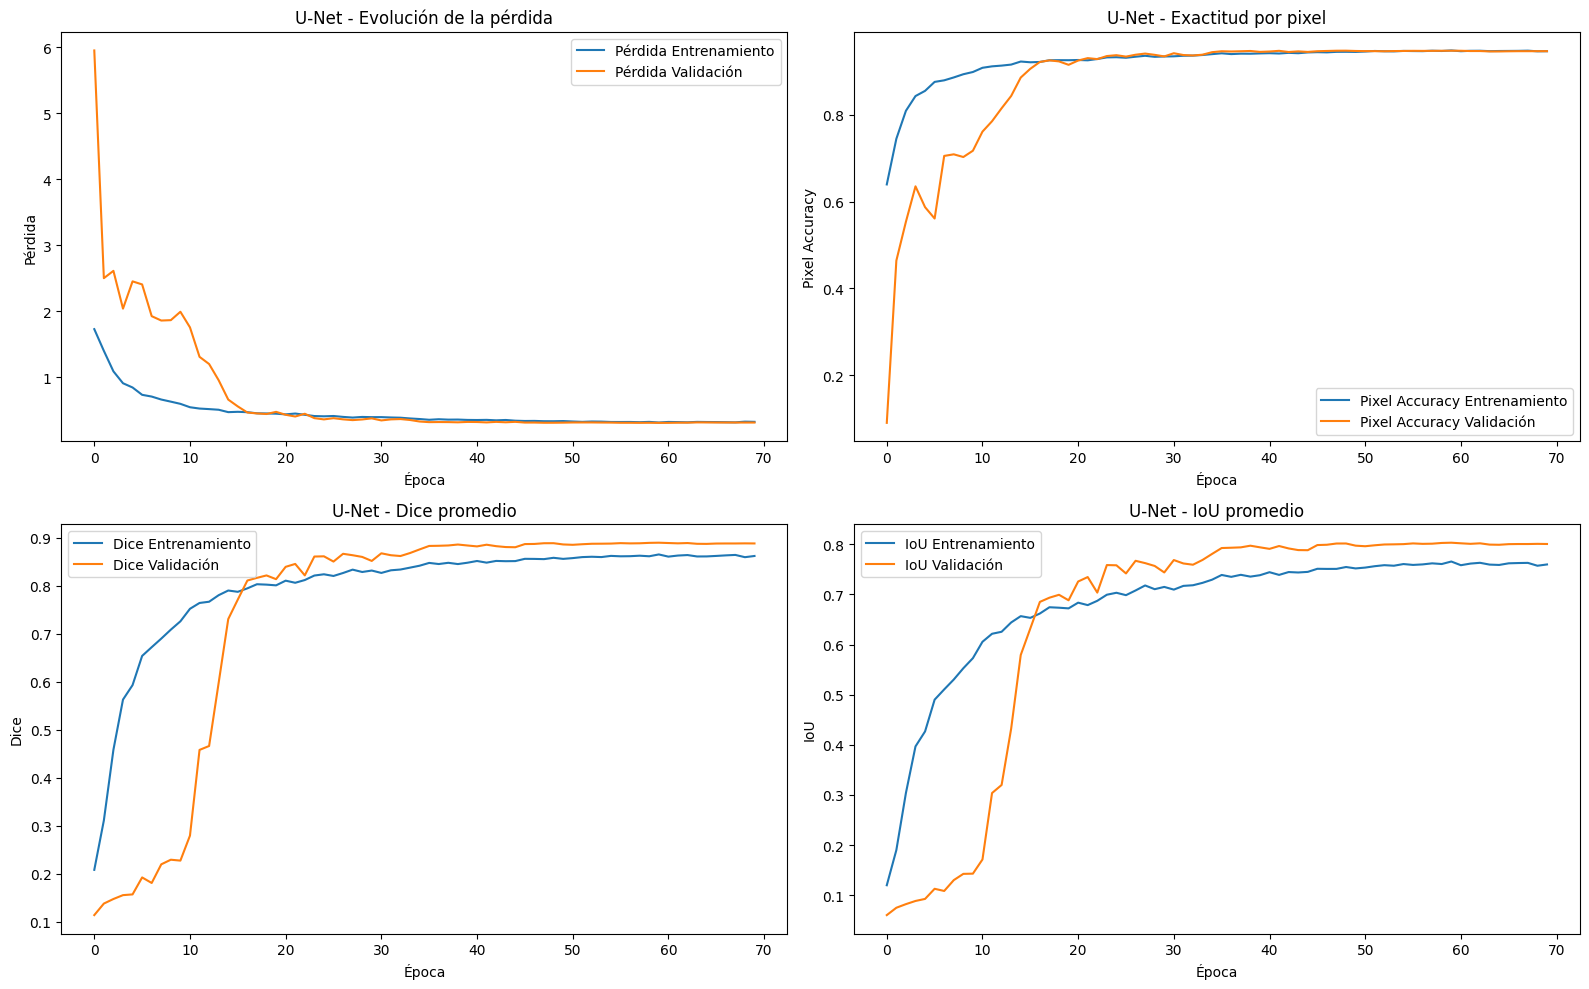

Gráficas de U-Net guardadas en:
/content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_80e/graficas_unet_mejorada.png


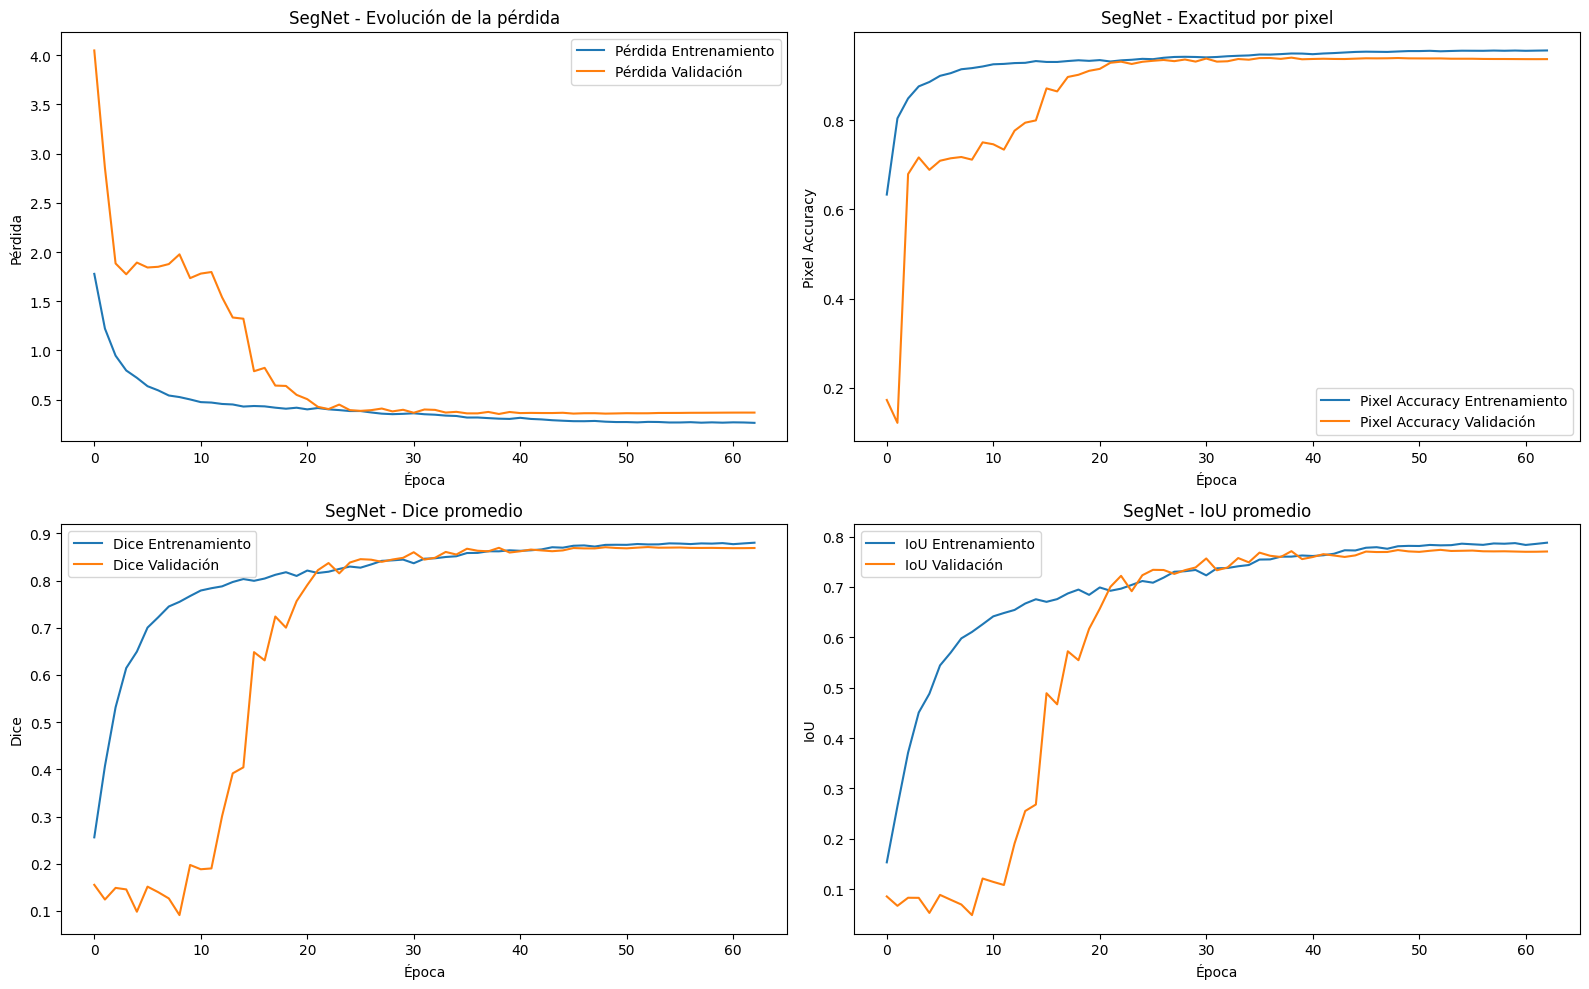

Gráficas de SegNet guardadas en:
/content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_80e/graficas_segnet.png


In [ ]:
# Graficar curvas de entrenamiento de U-Net
# -----------------------------------------
plt.figure(figsize=(16, 10))

# Pérdida
plt.subplot(2, 2, 1)
plt.plot(history_unet.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history_unet.history['val_loss'], label='Pérdida Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('U-Net - Evolución de la pérdida')
plt.legend()

# Exactitud por pixel
plt.subplot(2, 2, 2)
plt.plot(history_unet.history['pixel_accuracy'], label='Pixel Accuracy Entrenamiento')
plt.plot(history_unet.history['val_pixel_accuracy'], label='Pixel Accuracy Validación')
plt.xlabel('Época')
plt.ylabel('Pixel Accuracy')
plt.title('U-Net - Exactitud por pixel')
plt.legend()

# Dice
plt.subplot(2, 2, 3)
plt.plot(history_unet.history['mean_dice'], label='Dice Entrenamiento')
plt.plot(history_unet.history['val_mean_dice'], label='Dice Validación')
plt.xlabel('Época')
plt.ylabel('Dice')
plt.title('U-Net - Dice promedio')
plt.legend()

# IoU
plt.subplot(2, 2, 4)
plt.plot(history_unet.history['mean_iou'], label='IoU Entrenamiento')
plt.plot(history_unet.history['val_mean_iou'], label='IoU Validación')
plt.xlabel('Época')
plt.ylabel('IoU')
plt.title('U-Net - IoU promedio')
plt.legend()

plt.tight_layout()

grafica_unet_path = os.path.join(output_dir, 'graficas_unet_mejorada.png')
plt.savefig(grafica_unet_path, dpi=300, bbox_inches='tight')
plt.show()

print("Gráficas de U-Net guardadas en:")
print(grafica_unet_path)

# Graficar curvas de entrenamiento de SegNet
# -----------------------------------------
plt.figure(figsize=(16, 10))

# Pérdida
plt.subplot(2, 2, 1)
plt.plot(history_segnet.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history_segnet.history['val_loss'], label='Pérdida Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('SegNet - Evolución de la pérdida')
plt.legend()

# Exactitud por pixel
plt.subplot(2, 2, 2)
plt.plot(history_segnet.history['pixel_accuracy'], label='Pixel Accuracy Entrenamiento')
plt.plot(history_segnet.history['val_pixel_accuracy'], label='Pixel Accuracy Validación')
plt.xlabel('Época')
plt.ylabel('Pixel Accuracy')
plt.title('SegNet - Exactitud por pixel')
plt.legend()

# Dice
plt.subplot(2, 2, 3)
plt.plot(history_segnet.history['mean_dice'], label='Dice Entrenamiento')
plt.plot(history_segnet.history['val_mean_dice'], label='Dice Validación')
plt.xlabel('Época')
plt.ylabel('Dice')
plt.title('SegNet - Dice promedio')
plt.legend()

# IoU
plt.subplot(2, 2, 4)
plt.plot(history_segnet.history['mean_iou'], label='IoU Entrenamiento')
plt.plot(history_segnet.history['val_mean_iou'], label='IoU Validación')
plt.xlabel('Época')
plt.ylabel('IoU')
plt.title('SegNet - IoU promedio')
plt.legend()

plt.tight_layout()

grafica_segnet_path = os.path.join(output_dir, 'graficas_segnet.png')
plt.savefig(grafica_segnet_path, dpi=300, bbox_inches='tight')
plt.show()

print("Gráficas de SegNet guardadas en:")
print(grafica_segnet_path)


Compartiva visual U-Net vs SegNet

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 762ms/step


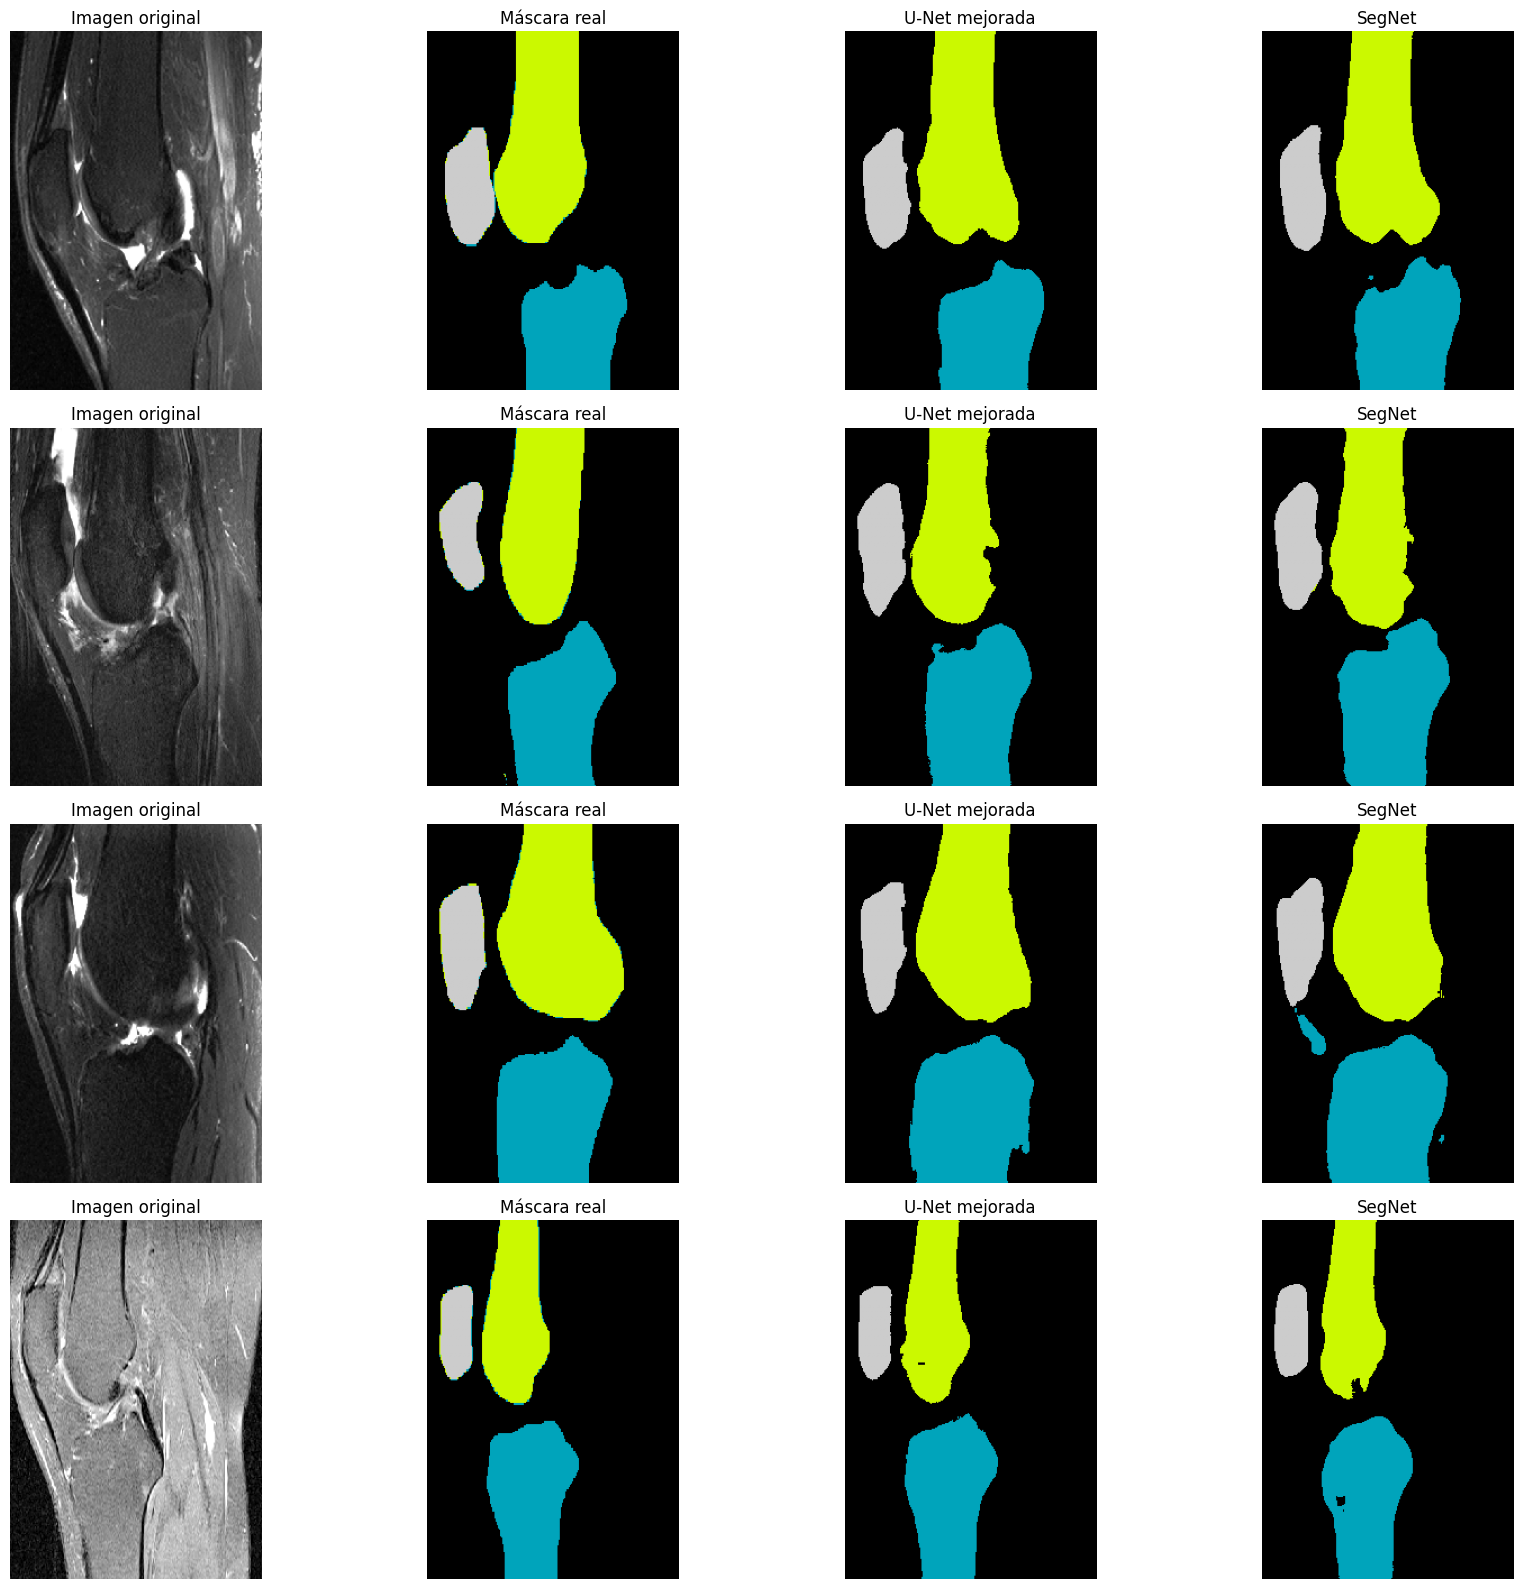

Comparación visual guardada en:
/content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_80e/comparacion_visual_unet_vs_segnet.png


In [ ]:
# Comparación visual U-Net vs SegNet
# ----------------------------------
# Imagen original | Máscara real | U-Net mejorada | SegNet

num_samples = 4
sample_images = images_val[:num_samples]
sample_masks = masks_val[:num_samples]

# Predicciones U-Net
preds_unet = model_unet.predict(sample_images)
preds_unet_classes = np.argmax(preds_unet, axis=-1)

# Predicciones SegNet
preds_segnet = model_segnet.predict(sample_images)
preds_segnet_classes = np.argmax(preds_segnet, axis=-1)

# Máscaras reales
true_classes = np.squeeze(sample_masks)

plt.figure(figsize=(18, num_samples * 4))

for i in range(num_samples):
    # Imagen original
    plt.subplot(num_samples, 4, i * 4 + 1)
    plt.imshow(sample_images[i].squeeze(), cmap='gray')
    plt.title('Imagen original')
    plt.axis('off')

    # Máscara real
    plt.subplot(num_samples, 4, i * 4 + 2)
    plt.imshow(
        true_classes[i],
        cmap='nipy_spectral',
        vmin=0,
        vmax=NUM_CLASSES - 1)
    plt.title('Máscara real')
    plt.axis('off')

    # U-Net mejorada
    plt.subplot(num_samples, 4, i * 4 + 3)
    plt.imshow(
        preds_unet_classes[i],
        cmap='nipy_spectral',
        vmin=0,
        vmax=NUM_CLASSES - 1)
    plt.title('U-Net mejorada')
    plt.axis('off')

    # SegNet
    plt.subplot(num_samples, 4, i * 4 + 4)
    plt.imshow(
        preds_segnet_classes[i],
        cmap='nipy_spectral',
        vmin=0,
        vmax=NUM_CLASSES - 1)
    plt.title('SegNet')
    plt.axis('off')

plt.tight_layout()

comparacion_visual_path = os.path.join(output_dir, 'comparacion_visual_unet_vs_segnet.png')
plt.savefig(comparacion_visual_path, dpi=300, bbox_inches='tight')

plt.show()
print("Comparación visual guardada en:")
print(comparacion_visual_path)

Guardar datos modelos entrenados

In [ ]:

# Cargar modelos guardados después, si se necesita
# ------------------------------------------------

custom_objects_dict = {
    'sparse_ce_dice_loss': sparse_ce_dice_loss,
    'mean_dice': mean_dice,
    'mean_iou': mean_iou}

print("\nRutas importantes:")
print("Mejor U-Net:", unet_best_path)
print("Modelo final U-Net:", unet_final_path)
print("Mejor SegNet:", segnet_best_path)
print("Modelo final SegNet:", segnet_final_path)

print("\nProceso terminado correctamente.")


Rutas importantes:
Mejor U-Net: /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_80e/UNet_Actual_best_20260526_000706.keras
Modelo final U-Net: /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_80e/UNet_Actual_final_20260526_000706.keras
Mejor SegNet: /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_80e/SegNet_Actual_best_20260526_002429.keras
Modelo final SegNet: /content/drive/MyDrive/Equipo Trifuerza/Modelos entrenados/Comparativa_Unet_SegNet_80e/SegNet_Actual_final_20260526_002429.keras

Proceso terminado correctamente.


##**5.1 Analísis de resultados**
**Métricas obtenidas**\
En los resultados de entrenamiento se observa que la pérdida disminuye progresivamente y las métricas de Dice e IoU aumentan hasta estabilizarse. Esto indica que el modelo aprendió patrones útiles del conjunto de datos.

También se observa que las curvas de entrenamiento y validación se mantienen cercanas, lo cual es una señal de buena generalización. En algunos casos, la validación incluso puede aparecer ligeramente por encima del entrenamiento, lo cual se puede explicar porque durante el entrenamiento se usó aumento de datos, generando imágenes más difíciles, mientras que la validación se hizo con imágenes sin transformación.

**Segmentaciones muestra obtenidas**\
En la comparación visual se puede observar que ambas arquitecturas logran segmentar las estructuras principales. Sin embargo, la U-Net mejorada conserva mejor la forma de las regiones anatómicas y presenta una segmentación más consistente en comparación con SegNet.

Esto se puede atribuir a sus conexiones de salto, que permiten recuperar información espacial fina durante la reconstrucción de la máscara.



# **7. Conclusiones**
A partir de la comparación experimental entre U-Net mejorada y SegNet, se observó que ambas arquitecturas lograron aprender patrones relevantes para la segmentación automática de estructuras anatómicas de rodilla. Sin embargo, la U-Net mejorada presentó una mayor correspondencia visual con las máscaras reales, mostrando mejor continuidad en las regiones segmentadas y una delimitación más precisa de las estructuras.

Esta diferencia puede explicarse por las conexiones de salto propias de U-Net, las cuales permiten recuperar información espacial fina del encoder y combinarla con la reconstrucción realizada por el decoder. En tareas de segmentación médica, esta característica resulta importante debido a que los bordes anatómicos y las estructuras pequeñas requieren alta precisión. Por otro lado, SegNet, al no utilizar concatenaciones directas entre encoder y decoder, puede perder parte de esa información espacial durante la etapa de reconstrucción.

Por lo tanto, para el conjunto de datos utilizado, la U-Net mejorada resultó ser la arquitectura más adecuada, ya que ofreció una segmentación más consistente y una mejor preservación de las formas anatómicas.


# **6. Referencias**
[1] C. Guaraca y T. Dolores, “Procesamiento de imágenes para detección de osteoartritis de rodilla utilizando IA,” 2024. [En línea]. Disponible: http://dspace.ups.edu.ec/handle/123456789/26961

[2] F. Segura, F. P. Segura, M. P. Lucero Zudaire, F. V. Segura,
R. Mendía, L. Ribotta Falco, P. S. Zalazar y Sequeira, “Clasificación avanzada de la artrosis de rodilla utilizando tecnologías de inteligencia artificial,” Rev. Asoc. Argent.Ortop. Traumatol., 2024. [En línea]. Disponible: https://doi.org/10.15417/issn.1852-7434.2024.89.5.1993

[3] GeeksforGeeks, «UNET Architecture explained», GeeksforGeeks, 9 de octubre de 2025. https://www.geeksforgeeks.org/machine-learning/u-net-architecture-explained/

[4] GeeksforGeeks, «SegNet: A Deep Convolutional EncoderDecoder Architecture for Image Segmentation.», GeeksforGeeks, 23 de julio de 2025. https://www.geeksforgeeks.org/computer-vision segnet-a-deep-convolutional-encoder-decoder-architecture-for-image-segmentation/

[5] «SegNet: A Deep Convolutional Encoder-Decoder Architecture for Image Segmentation», IEEE Journals & Magazine | IEEE Xplore, 1 de diciembre de 2017. https://ieeexplore.ieee.org/document/7803544

[6] L. L. Hurtado-Cortés, E. Villarreal-López y L. VillarrealLópez, “Detección y diagnóstico de fallas mediante técnicas de
inteligencia artificial, un estado del arte,” Dyna, vol. 83, no.
199, pp. 19–28, 2016.

[7] “KneeScans,” Kaggle, 20 feb. 2020. [En línea]. Disponible:
https://www.kaggle.com/datasets/henryhaefliger/kneescans/dat
a
[8] “KneeMRIDataset,” Kaggle, 15 ene. 2019. [En línea].
Disponible:https://www.kaggle.com/datasets/sohaibanwaar12
03/kneemridataset

